# Modelo No. 2

## 1. Importaciones y utilidades

In [3]:
import os
import cv2
import numpy as np
from datetime import datetime
import mediapipe as mp
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.regularizers import l2
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from keras.models import load_model
from mediapipe.python.solutions.holistic import Holistic
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ROOT_PATH = "data"
FRAME_ACTIONS_PATH = "frases"  # carpeta por palabra/frase
FONT = cv2.FONT_HERSHEY_SIMPLEX
FONT_SIZE = 1
FONT_POS = (10, 30)

# Crear carpeta si no existe
def create_folder(path):
    if not os.path.exists(path):
        os.makedirs(path)

# Detectar si hay manos en los resultados
def there_hand(results):
    return results.left_hand_landmarks or results.right_hand_landmarks

# Dibujar los keypoints de las manos
def draw_keypoints(image, results):
    if results.left_hand_landmarks:
        mp.solutions.drawing_utils.draw_landmarks(image, results.left_hand_landmarks, mp.solutions.holistic.HAND_CONNECTIONS)
    if results.right_hand_landmarks:
        mp.solutions.drawing_utils.draw_landmarks(image, results.right_hand_landmarks, mp.solutions.holistic.HAND_CONNECTIONS)

# Aplicar MediaPipe
def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image.flags.writeable = False
    results = model.process(image)
    return results

# Extraer keypoints de ambas manos
def extract_keypoints(results):
    lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21 * 3)
    rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21 * 3)
    return np.concatenate([lh, rh])

## 2. Captura de muestras

In [8]:
def capture_samples_npy(path, margin_frame=1, min_cant_frames=30, delay_frames=3):
    '''
    CAPTURA DE MUESTRAS PARA UNA PALABRA Y GUARDA KEYPOINTS COMO .NPY

    path: ruta base de la palabra (se creará una carpeta por muestra)
    margin_frame: frames ignorados al inicio/final
    min_cant_frames: mínimo de frames válidos requeridos
    delay_frames: frames extra que espera antes de cortar grabación
    '''
    create_folder(path)

    count_frame = 0
    sequence = []
    fix_frames = 0
    recording = False

    # Detectar cuántos registros ya hay
    registro_actual = len([f for f in os.listdir(path) if f.endswith(".npy")]) + 1

    cap = cv2.VideoCapture(2)
    with mp.solutions.holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic_model:

        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break

            image = frame.copy()
            results = mediapipe_detection(frame, holistic_model)

            if there_hand(results) or recording:
                recording = False
                count_frame += 1
                if count_frame > margin_frame:
                    cv2.putText(image, f'Registro {registro_actual}...', (10, 30), FONT, FONT_SIZE, (100, 200, 255), 2)
                    cv2.putText(
                        image,
                        'Capturando...',
                        (20, image.shape[0] - 20),  # Abajo izquierda
                        FONT,
                        FONT_SIZE,
                        (0, 50, 255),  # Azul fuerte
                        2
                    )
                    keypoints = extract_keypoints(results)
                    sequence.append(keypoints)
            else:
                if len(sequence) >= min_cant_frames + margin_frame:
                    fix_frames += 1
                    if fix_frames < delay_frames:
                        recording = True
                        continue

                    # Cortar exceso
                    sequence = sequence[: - (margin_frame + delay_frames)]
                    if len(sequence) < min_cant_frames:
                        print("⚠️ Muestra descartada por ser muy corta.")
                    else:
                        timestamp = datetime.now().strftime('%y%m%d%H%M%S%f')
                        npy_path = os.path.join(path, f'sample_{timestamp}.npy')
                        np.save(npy_path, np.array(sequence))
                        print(f"✅ Muestra guardada: {npy_path}")
                        registro_actual += 1

                recording, fix_frames = False, 0
                sequence, count_frame = [], 0
                cv2.putText(image, f'Registro {registro_actual}...', (10, 30), FONT, FONT_SIZE, (100, 200, 255), 2)
                cv2.putText(
                    image,
                    'Listo para capturar...',
                    (20, image.shape[0] - 20),  # Abajo izquierda
                    FONT,
                    FONT_SIZE,
                    (0, 220, 100),  # Verde fuerte
                    2
                )

            draw_keypoints(image, results)
            cv2.imshow(f'Toma de muestras (keypoints) para \"{os.path.basename(path)}\"', image)
            if cv2.waitKey(10) & 0xFF == ord('q'):
                break

    cap.release()
    cv2.destroyAllWindows()
    
if __name__ == "__main__":
    palabra = "gracias"
    word_path = os.path.join(ROOT_PATH, FRAME_ACTIONS_PATH, palabra)
    capture_samples_npy(word_path)

libEGL warning: MESA-LOADER: failed to open iris: /usr/lib/dri/iris_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open iris: /usr/lib/dri/iris_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open swrast: /usr/lib/dri/swrast_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open iris: /usr/lib/dri/iris_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open iris: /usr/lib/dri/iris_dri.so: cannot open shared object file: 

✅ Muestra guardada: data/frases/gracias/sample_250801123054842324.npy
✅ Muestra guardada: data/frases/gracias/sample_250801123125915298.npy
✅ Muestra guardada: data/frases/gracias/sample_250801123129792771.npy
✅ Muestra guardada: data/frases/gracias/sample_250801123133824495.npy
✅ Muestra guardada: data/frases/gracias/sample_250801123138149418.npy
✅ Muestra guardada: data/frases/gracias/sample_250801123142237593.npy
✅ Muestra guardada: data/frases/gracias/sample_250801123146275781.npy
✅ Muestra guardada: data/frases/gracias/sample_250801123150203787.npy
✅ Muestra guardada: data/frases/gracias/sample_250801123153878690.npy
✅ Muestra guardada: data/frases/gracias/sample_250801123157151043.npy
✅ Muestra guardada: data/frases/gracias/sample_250801123201645142.npy
✅ Muestra guardada: data/frases/gracias/sample_250801123255210460.npy
✅ Muestra guardada: data/frases/gracias/sample_250801123259182578.npy
✅ Muestra guardada: data/frases/gracias/sample_250801123302462298.npy
✅ Muestra guardada: 

## 3. Normalización

In [9]:
ROOT_PATH = "data"
FRAME_ACTIONS_PATH = "frases"
MODEL_FRAMES = 30  

def normalize_keypoints_sequence(sequence, target_len=30):
    current_len = len(sequence)
    if current_len == target_len:
        return sequence
    elif current_len > target_len:
        # Reducir seleccionando frames uniformemente
        step = current_len / target_len
        indices = np.arange(0, current_len, step).astype(int)[:target_len]
        return sequence[indices]
    else:
        # Interpolar si es menor
        indices = np.linspace(0, current_len - 1, target_len)
        interpolated = []
        for i in indices:
            lower = int(np.floor(i))
            upper = int(np.ceil(i))
            weight = i - lower
            if upper >= current_len:
                upper = current_len - 1
            interpolated_frame = (1 - weight) * sequence[lower] + weight * sequence[upper]
            interpolated.append(interpolated_frame)
        return np.array(interpolated)

def process_npy_directory(word_directory, target_len=30):
    for fname in os.listdir(word_directory):
        if fname.endswith(".npy"):
            full_path = os.path.join(word_directory, fname)
            sequence = np.load(full_path)
            normalized = normalize_keypoints_sequence(sequence, target_len)
            np.save(full_path, normalized)
            print(f"✅ Normalizado: {fname} → {normalized.shape}")

if __name__ == "__main__":
    word_ids = [w for w in os.listdir(os.path.join(ROOT_PATH, FRAME_ACTIONS_PATH))]

    for word_id in word_ids:
        word_path = os.path.join(ROOT_PATH, FRAME_ACTIONS_PATH, word_id)
        if os.path.isdir(word_path):
            print(f"\n📦 Normalizando muestras de: {word_id}")
            process_npy_directory(word_path, target_len=MODEL_FRAMES)


📦 Normalizando muestras de: hola
✅ Normalizado: sample_250801120741011638.npy → (30, 126)
✅ Normalizado: sample_250801115714533398.npy → (30, 126)
✅ Normalizado: sample_250801120451093775.npy → (30, 126)
✅ Normalizado: sample_250801115059697238.npy → (30, 126)
✅ Normalizado: sample_250801120547439548.npy → (30, 126)
✅ Normalizado: sample_250801115114074355.npy → (30, 126)
✅ Normalizado: sample_250801121119408161.npy → (30, 126)
✅ Normalizado: sample_250801115616172702.npy → (30, 126)
✅ Normalizado: sample_250801120712963264.npy → (30, 126)
✅ Normalizado: sample_250801120551437225.npy → (30, 126)
✅ Normalizado: sample_250801120734069640.npy → (30, 126)
✅ Normalizado: sample_250801115236570857.npy → (30, 126)
✅ Normalizado: sample_250801115710628972.npy → (30, 126)
✅ Normalizado: sample_250801115908438429.npy → (30, 126)
✅ Normalizado: sample_250801120356217293.npy → (30, 126)
✅ Normalizado: sample_250801120703888977.npy → (30, 126)
✅ Normalizado: sample_250801120940123252.npy → (30, 12

## 4. Entrenamiento

In [4]:
# Número total de keypoints por frame: 21 puntos × 3 coords × 2 manos
LENGTH_KEYPOINTS = 126  
MODEL_FRAMES = 30
MODEL_PATH = "action.h5"

def load_dataset(base_path="data/frases"):
    X = []
    y = []
    label_map = {}

    palabras = sorted(os.listdir(base_path))
    for idx, palabra in enumerate(palabras):
        label_map[palabra] = idx
        palabra_path = os.path.join(base_path, palabra)
        for archivo in os.listdir(palabra_path):
            if archivo.endswith(".npy"):
                secuencia = np.load(os.path.join(palabra_path, archivo))
                if secuencia.shape[0] == MODEL_FRAMES:
                    X.append(secuencia)
                    y.append(idx)

    X = np.array(X)
    y = to_categorical(np.array(y))
    return X, y, label_map

In [5]:
def get_model(max_length_frames, output_length: int):
    model = Sequential()
    model.add(LSTM(64, return_sequences=True, input_shape=(max_length_frames, LENGTH_KEYPOINTS), kernel_regularizer=l2(0.01)))
    model.add(Dropout(0.5))
    model.add(LSTM(128, return_sequences=False, kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.5))
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dense(output_length, activation='softmax'))

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

✅ Total muestras: 320, Clases: 2


2025-08-01 17:36:23.481986: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-08-01 17:36:23.483505: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1956] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2025-08-01 17:36:23.651626: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gra

Epoch 1/150


2025-08-01 17:36:23.757551: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-08-01 17:36:23.758447: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-08-01 17:36:23.759057: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

38/38 [==============================] - ETA: 0s - loss: 1.8038 - accuracy: 0.8059

2025-08-01 17:36:26.070106: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-08-01 17:36:26.071211: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-08-01 17:36:26.071872: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

38/38 [==============================] - 3s 23ms/step - loss: 1.8038 - accuracy: 0.8059 - val_loss: 1.0247 - val_accuracy: 1.0000
Epoch 2/150
38/38 [==============================] - 0s 12ms/step - loss: 0.8709 - accuracy: 0.9803 - val_loss: 0.6571 - val_accuracy: 1.0000
Epoch 3/150
38/38 [==============================] - 0s 11ms/step - loss: 0.5563 - accuracy: 1.0000 - val_loss: 0.4663 - val_accuracy: 1.0000
Epoch 4/150
38/38 [==============================] - 1s 15ms/step - loss: 0.4098 - accuracy: 1.0000 - val_loss: 0.3581 - val_accuracy: 1.0000
Epoch 5/150
38/38 [==============================] - 0s 11ms/step - loss: 0.3234 - accuracy: 1.0000 - val_loss: 0.2907 - val_accuracy: 1.0000
Epoch 6/150
38/38 [==============================] - 0s 9ms/step - loss: 0.2671 - accuracy: 1.0000 - val_loss: 0.2438 - val_accuracy: 1.0000
Epoch 7/150
38/38 [==============================] - 0s 9ms/step - loss: 0.2263 - accuracy: 1.0000 - val_loss: 0.2085 - val_accuracy: 1.0000
Epoch 8/150
38/38 [=

2025-08-01 17:36:56.875467: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-08-01 17:36:56.876417: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-08-01 17:36:56.877044: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

1/1 [==============================] - 0s 370ms/step


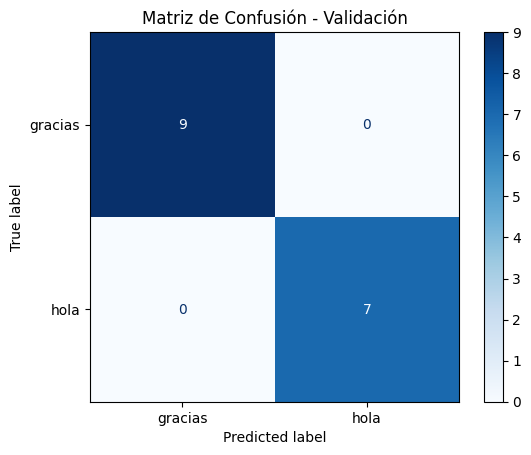


📊 Accuracy final - Entrenamiento: 1.00, Validación: 1.00
✅ Buen desempeño general


In [20]:
def train_model_from_npy(epochs=300):
    X, y, label_map = load_dataset()
    print(f"✅ Total muestras: {X.shape[0]}, Clases: {len(label_map)}")

    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.05, random_state=42)

    model = get_model(MODEL_FRAMES, output_length=len(label_map))

    early_stop = EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True, verbose=1)

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=8,
        callbacks=[early_stop],
        verbose=1
    )

    model.save(MODEL_PATH)
    print(f"💾 Modelo guardado en: {MODEL_PATH}")

    # 📊 Matriz de Confusión
    y_pred = model.predict(X_val)
    y_pred_labels = np.argmax(y_pred, axis=1)
    y_true = np.argmax(y_val, axis=1)
    WORDS = list(label_map.keys())

    cm = confusion_matrix(y_true, y_pred_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=WORDS)
    disp.plot(cmap="Blues", values_format=".0f")
    plt.title("Matriz de Confusión - Validación")
    plt.show()

    # 📈 Diagnóstico
    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    print(f"\n📊 Accuracy final - Entrenamiento: {train_acc:.2f}, Validación: {val_acc:.2f}")
    if abs(train_acc - val_acc) > 0.2:
        print("⚠️ Posible overfitting")
    elif max(history.history['val_accuracy']) < 0.6:
        print("⚠️ Posible underfitting")
    else:
        print("✅ Buen desempeño general")

    return model, label_map

model, label_map = train_model_from_npy(epochs=150)

## 5. Validaciones

In [6]:
LENGTH_KEYPOINTS = 126

def get_model(max_length_frames, output_length: int):
    model = Sequential()
    model.add(LSTM(64, return_sequences=True, input_shape=(max_length_frames, LENGTH_KEYPOINTS), kernel_regularizer=l2(0.01)))
    model.add(Dropout(0.5))
    model.add(LSTM(128, return_sequences=False, kernel_regularizer=l2(0.001)))
    model.add(Dropout(0.5))
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(Dense(output_length, activation='softmax'))
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [7]:
MODEL_PATH = "action.h5"
DATA_PATH = "data/frases"
WORDS = sorted(os.listdir(DATA_PATH))  # nombres de las clases
MODEL_FRAMES = 30
MIN_LENGTH_FRAMES = 10
FONT = cv2.FONT_HERSHEY_SIMPLEX
FONT_POS = (10, 30)
FONT_SIZE = 1

def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image.flags.writeable = False
    return model.process(image)

def there_hand(results):
    return results.left_hand_landmarks or results.right_hand_landmarks

def extract_keypoints(results):
    lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]) if results.left_hand_landmarks else np.zeros((21, 3))
    rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]) if results.right_hand_landmarks else np.zeros((21, 3))
    return np.concatenate([lh, rh]).flatten()

def normalize_keypoints(keypoints, target_length=30):
    current_length = len(keypoints)
    if current_length == target_length:
        return keypoints
    elif current_length > target_length:
        step = current_length / target_length
        indices = np.arange(0, current_length, step).astype(int)[:target_length]
        return [keypoints[i] for i in indices]
    else:
        indices = np.linspace(0, current_length - 1, target_length)
        interpolated = []
        for i in indices:
            lower = int(np.floor(i))
            upper = int(np.ceil(i))
            weight = i - lower
            if lower == upper:
                interpolated.append(keypoints[lower])
            else:
                interpolated.append(((1 - weight) * np.array(keypoints[lower]) + weight * np.array(keypoints[upper])).tolist())
        return interpolated

def draw_keypoints(image, results):
    mp_drawing = mp.solutions.drawing_utils
    if results.left_hand_landmarks:
        mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp.solutions.holistic.HAND_CONNECTIONS)
    if results.right_hand_landmarks:
        mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp.solutions.holistic.HAND_CONNECTIONS)

In [8]:
def evaluate_model(threshold=0.8, margin_frame=1, delay_frames=3, src=0):
    print("🟡 Cargando modelo...")
    model = load_model(MODEL_PATH)

    print("📷 Inicializando cámara...")
    cap = cv2.VideoCapture(src)
    if not cap.isOpened():
        print("❌ No se pudo abrir la cámara.")
        return

    sentence = []
    pred_label = ""
    pred_prob = 0.0
    kp_seq, count_frame, fix_frames = [], 0, 0
    recording = False

    with Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
        print("🎥 Traductor en vivo iniciado. Presiona 'q' para salir.")
        while True:
            ret, frame = cap.read()
            if not ret:
                print("⚠️ No se pudo leer el frame de la cámara.")
                break

            results = mediapipe_detection(frame, holistic)

            if there_hand(results) or recording:
                recording = False
                count_frame += 1
                if count_frame > margin_frame:
                    kp_frame = extract_keypoints(results)
                    kp_seq.append(kp_frame)
            else:
                if count_frame >= MIN_LENGTH_FRAMES + margin_frame:
                    fix_frames += 1
                    if fix_frames < delay_frames:
                        recording = True
                        continue

                    kp_seq = kp_seq[: -(margin_frame + delay_frames)]
                    kp_normalized = normalize_keypoints(kp_seq, target_length=MODEL_FRAMES)
                    input_data = np.expand_dims(np.array(kp_normalized), axis=0)

                    prediction = model.predict(input_data, verbose=0)[0]
                    max_idx = np.argmax(prediction)
                    max_prob = prediction[max_idx]

                    if max_prob > threshold:
                        pred_label = WORDS[max_idx]
                        pred_prob = max_prob * 100
                        sentence.insert(0, pred_label)

                kp_seq = []
                count_frame = 0
                fix_frames = 0
                recording = False

            # Mostrar texto y porcentaje en ventana
            cv2.rectangle(frame, (0, 0), (640, 60), (245, 117, 16), -1)
            cv2.putText(frame, f'{pred_label.upper()} ({pred_prob:.1f}%)', FONT_POS, FONT, FONT_SIZE, (255, 255, 255), 2)

            draw_keypoints(frame, results)
            cv2.imshow('Traductor LSP', frame)

            if cv2.waitKey(10) & 0xFF == ord('q'):
                print("🛑 Cerrando traductor.")
                break

        cap.release()
        cv2.destroyAllWindows()

if __name__ == "__main__":
    evaluate_model()

🟡 Cargando modelo...


2025-08-02 14:31:41.288445: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-08-02 14:31:41.290678: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1956] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2025-08-02 14:31:41.491848: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gra

📷 Inicializando cámara...


libEGL warning: MESA-LOADER: failed to open iris: /usr/lib/dri/iris_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open iris: /usr/lib/dri/iris_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open swrast: /usr/lib/dri/swrast_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open iris: /usr/lib/dri/iris_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)

libEGL warning: MESA-LOADER: failed to open iris: /usr/lib/dri/iris_dri.so: cannot open shared object file: 

🎥 Traductor en vivo iniciado. Presiona 'q' para salir.


W0000 00:00:1754166702.900519    8869 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.
2025-08-02 14:31:49.385545: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-08-02 14:31:49.386729: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-08-02 14:31:

🛑 Cerrando traductor.
